# Random walks and diffusion

I begin with molecules at the origin on an unbounded two-dimensional lattice. Each step moves one lattice spacing in a cardinal direction. Position is measured in lattice spacings and time in sweeps. One sweep moves every molecule once. Mean-square displacement is the average squared distance from the starting point, in squared lattice spacings. The diffusion coefficient for this convention is 1/4 lattice-spacing squared per sweep.

I write one part, test it, then continue. Run the cells in order. This short lesson checks the method; it does not replace the complete simulation or establish convergence.

**Using my code.** I permit free noncommercial teaching, learning and demonstrations with acknowledgment. Research (including academic research) and commercial use require my explicit written permission. Earlier MIT and GPL releases retain their existing permissions. Read the [code-use terms](https://saswataiith.github.io/files/CODE-USE-TERMS.txt). Request permission at saswata_at_msme.iith.ac.in. These terms apply to code; teaching text and figures have separate terms.


## 1. Set the positions and allowed moves

I first check the move lengths. No boundary rule is applied to the positions: the histogram window used by the complete program is only a display window.

In [1]:
import numpy as np
rng = np.random.default_rng(7)
number = 50000
positions = np.zeros((number, 2), dtype=int)
moves = np.array([[1, 0], [-1, 0], [0, 1], [0, -1]])
assert np.all(np.sum(moves**2, axis=1) == 1)
assert np.all(positions == 0)
print("Molecules:", number)

Molecules: 50000


## 2. Take one sweep

I choose a direction independently for each molecule. After the first sweep every molecule is exactly one lattice spacing from the origin.

In [2]:
choices = rng.integers(0, 4, number)
positions += moves[choices]
assert np.all(np.sum(positions**2, axis=1) == 1)
print("Mean-square displacement after one sweep:", np.mean(np.sum(positions**2, axis=1)))

Mean-square displacement after one sweep: 1.0


## 3. Measure displacement over many sweeps

The predicted ensemble mean-square displacement equals the sweep count. An individual finite sample fluctuates. I therefore use a stated statistical tolerance instead of requiring exact equality. The seed makes this NumPy run repeatable; Julia uses a different random generator.

In [3]:
sweep_count = 100
history = [0.0, 1.0]
for sweep in range(2, sweep_count + 1):
    choices = rng.integers(0, 4, number)
    positions += moves[choices]
    history.append(float(np.mean(np.sum(positions**2, axis=1))))
relative_error = abs(history[-1] / sweep_count - 1)
assert relative_error < 0.06
print("Measured:", history[-1], "prediction:", sweep_count)
print("Relative error:", relative_error)

Measured: 99.4042 prediction: 100
Relative error: 0.005958000000000019


## 4. Separate individual motion from spreading

A molecule continues making discrete random steps. Diffusion describes the distribution of many molecules. The mean displacement should be small compared with the root-mean-square distance. The check below is an ensemble check for this seeded example, not a universal bound.

Mean position: [0.01118 0.05158]
Root-mean-square distance: 9.970165495115916


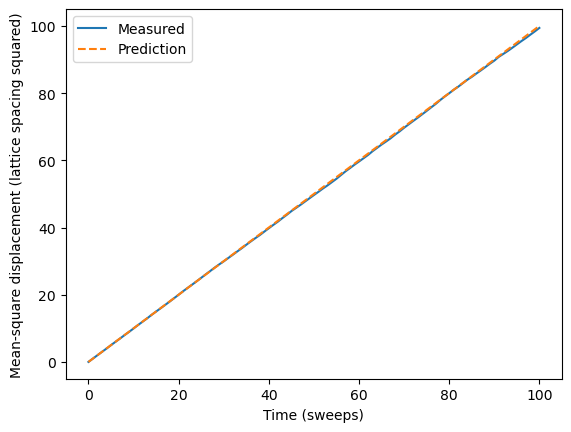

In [4]:
mean_position = positions.mean(axis=0)
root_mean_square_distance = np.sqrt(history[-1])
assert np.linalg.norm(mean_position) < 0.1 * root_mean_square_distance
print("Mean position:", mean_position)
print("Root-mean-square distance:", root_mean_square_distance)

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(range(sweep_count + 1), history, label="Measured")
ax.plot(range(sweep_count + 1), range(sweep_count + 1), "--", label="Prediction")
ax.set_xlabel("Time (sweeps)")
ax.set_ylabel("Mean-square displacement (lattice spacing squared)")
ax.legend()
plt.show()

## Continue with the complete program

The original complete program is `../walkers.py`. Its parameters, source credits and output commands are retained. These short examples use smaller workloads for learning; they are not a rerun of every result on the website.